 #  *Volkswagen India Sales Analytics*

## Data Cleaning in Python

In [1]:
import pandas as pd

In [22]:
df = pd.read_csv('vw_india_sales_data (1).csv')

In [23]:
df.head()

,sale_id,date,year,month,month_name,state,city,model,segment,fuel,price_lakh,customer_age_band,customer_gender,customer_occupation,payment_mode,sales_channel,csat_score,is_repeat_customer
0,100001,2024-01-01,2024,1,Jan,Maharashtra,Mumbai,Virtus,Sedan,Petrol,13.49,18-25,Female,Salaried - Private,Loan/Finance,Online Enquiry,4,1
1,100002,2024-01-01,2024,1,Jan,Maharashtra,Mumbai,Virtus,Sedan,Petrol,16.37,36-45,Female,Self-Employed/Business,Loan/Finance,Showroom Walk-in,2,0
2,100003,2024-01-01,2024,1,Jan,Maharashtra,Mumbai,Taigun,SUV,Petrol,17.86,46-55,Male,Salaried - Private,Loan/Finance,Referral,4,0
3,100004,2024-01-01,2024,1,Jan,Maharashtra,Mumbai,Taigun,SUV,Petrol,18.50,36-45,Male,Professional (Doctor/CA/Lawyer),Loan/Finance,Showroom Walk-in,2,0
4,100005,2024-01-01,2024,1,Jan,Maharashtra,Mumbai,Taigun,SUV,Petrol,17.66,36-45,Female,Professional (Doctor/CA/Lawyer),Cash/Full Payment,Online Enquiry,4,1


In [24]:
df.isnull().sum()

sale_id                0
date                   0
year                   0
month                  0
month_name             0
state                  0
city                   0
model                  0
segment                0
fuel                   0
price_lakh             0
customer_age_band      0
customer_gender        0
customer_occupation    0
payment_mode           0
sales_channel          0
csat_score             0
is_repeat_customer     0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6914 entries, 0 to 6913
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              6914 non-null   int64  
 1   date                 6914 non-null   object 
 2   year                 6914 non-null   int64  
 3   month                6914 non-null   int64  
 4   month_name           6914 non-null   object 
 5   state                6914 non-null   object 
 6   city                 6914 non-null   object 
 7   model                6914 non-null   object 
 8   segment              6914 non-null   object 
 9   fuel                 6914 non-null   object 
 10  price_lakh           6914 non-null   float64
 11  customer_age_band    6914 non-null   object 
 12  customer_gender      6914 non-null   object 
 13  customer_occupation  6914 non-null   object 
 14  payment_mode         6914 non-null   object 
 15  sales_channel        6914 non-null   o

In [32]:
df.describe()

,sale_id,date,year,month,price_lakh,csat_score,is_repeat_customer
count,6914.000000,6914,6914.000000,6914.000000,6914.000000,6914.000000,6914.000000
mean,103457.500000,2025-01-01 10:02:07.046572288,2024.528493,6.700607,15.577021,3.926960,0.185999
min,100001.000000,2024-01-01 00:00:00,2024.000000,1.000000,7.650000,1.000000,0.000000
25%,101729.250000,2024-07-01 00:00:00,2024.000000,4.000000,13.172500,3.000000,0.000000
50%,103457.500000,2025-01-01 00:00:00,2025.000000,7.000000,15.655000,4.000000,0.000000
75%,105185.750000,2025-07-01 00:00:00,2025.000000,10.000000,16.880000,5.000000,0.000000
max,106914.000000,2025-12-01 00:00:00,2025.000000,12.000000,43.220000,5.000000,1.000000
std,1996.044213,NaN,0.499224,3.486252,5.881063,1.091245,0.389134


In [28]:
df['date'] = pd.to_datetime(df['date'])


In [29]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [33]:
df['revenue_lakh'] = df['price_lakh']

In [34]:
df['revenue_rs'] = df['price_lakh'] * 100000

In [35]:
df['quarter'] = df['date'].dt.quarter

In [36]:
df['month_year'] = df['date'].dt.strftime('%b-%Y')

## Exploratory Data Analysis

In [37]:
# Total Revenue
df['revenue_lakh'].sum()

np.float64(107699.51999999999)

In [38]:
# Total Cars Sold
len(df)

6914

In [39]:
# Average Vehicle Price
df['price_lakh'].mean()

np.float64(15.577020538038761)

In [40]:
# Average Customer Satisfaction
df['csat_score'].mean()

np.float64(3.9269597917269308)

## Sales Trend Analysis

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='month_year'>

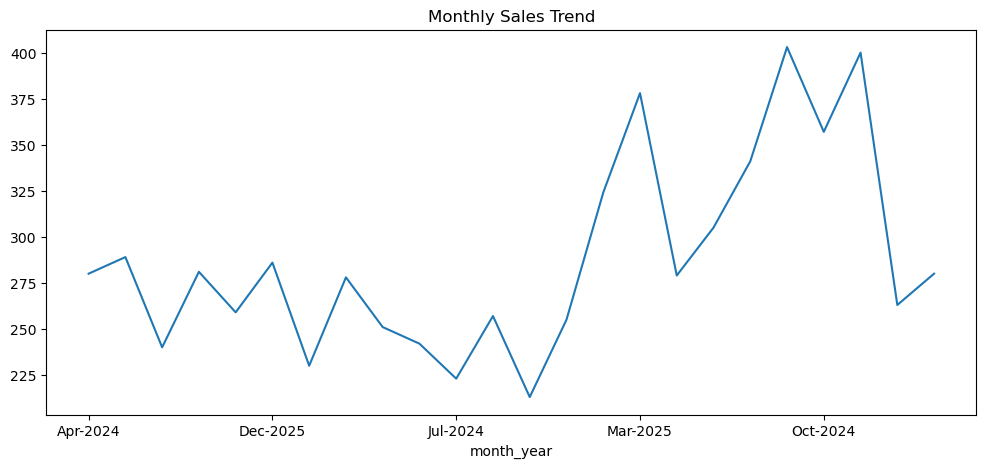

In [45]:
monthly_sales = df.groupby('month_year').size()
monthly_sales.plot(figsize=(12,5),title="Monthly Sales Trend")

## Revenue by Model

<Axes: xlabel='model'>

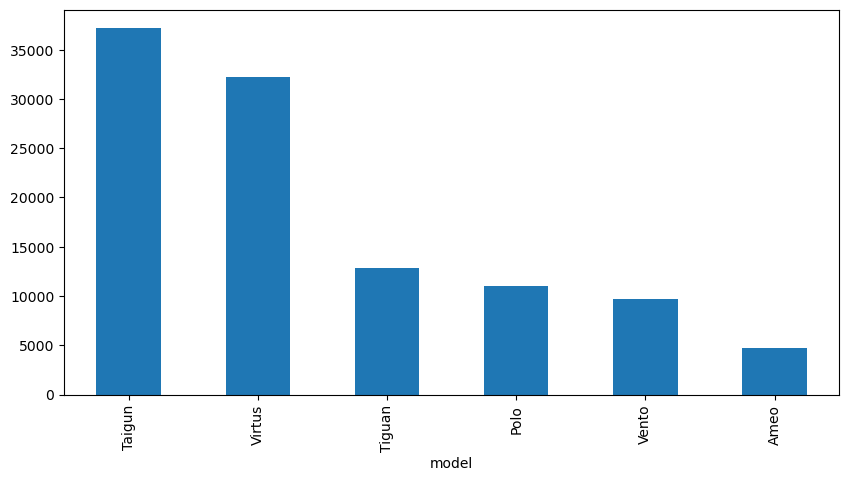

In [46]:
model_sales = df.groupby('model')['revenue_lakh'].sum()
model_sales.sort_values(ascending=False).plot( kind='bar', figsize=(10,5))

## State Analysis

In [47]:
state_sales = df.groupby('state').agg({'sale_id':'count', 'revenue_lakh':'sum'})
state_sales.sort_values('revenue_lakh',ascending=False)

,sale_id,revenue_lakh
state,,
Maharashtra,1242,19382.80
Karnataka,710,10949.40
Tamil Nadu,660,10334.98
Gujarat,629,9738.67
Uttar Pradesh,630,9648.29
Delhi,575,9034.09
Telangana,480,7304.84
Haryana,435,6767.34
West Bengal,310,4923.05


## City Analysis

In [48]:
city_sales = df.groupby('city').agg({'sale_id':'count','revenue_lakh':'sum'})
city_sales.sort_values( 'revenue_lakh', ascending=False)

,sale_id,revenue_lakh
city,,
New Delhi,575,9034.09
Mumbai,586,9004.01
Bengaluru,551,8490.86
Hyderabad,480,7304.84
Pune,459,7226.19
Chennai,446,7044.10
Gurugram,435,6767.34
Ahmedabad,374,5813.28
Noida,350,5385.47


## Segment Analysis

In [49]:
segment_sales = df.groupby('segment').agg({'sale_id':'count','revenue_lakh':'sum'})
segment_sales

,sale_id,revenue_lakh
segment,,
Hatchback,1170,10998.63
SUV,2540,50043.54
Sedan,3204,46657.35


## Fuel Type Analysis

In [52]:
fuel_sales = df.groupby('fuel').agg({ 'sale_id':'count', 'revenue_lakh':'sum'})
fuel_sales

,sale_id,revenue_lakh
fuel,,
Petrol,6914,107699.52


## Customer Demographics

In [53]:
# Age Band
df['customer_age_band'].value_counts()

customer_age_band
26-35    2350
36-45    2136
46-55    1215
56-65     620
18-25     359
65+       234
Name: count, dtype: int64

In [54]:
# Gender
df['customer_gender'].value_counts()

customer_gender
Male      5337
Female    1577
Name: count, dtype: int64

In [55]:
# Occupation
df['customer_occupation'].value_counts()

customer_occupation
Salaried - Private                 3184
Self-Employed/Business             1945
Professional (Doctor/CA/Lawyer)     822
Salaried - Government               669
Retired                             294
Name: count, dtype: int64

## Payment Mode Analysis

In [57]:
payment_analysis = df.groupby('payment_mode')['sale_id'].count()
payment_analysis

payment_mode
Cash/Full Payment    1919
Loan/Finance         4995
Name: sale_id, dtype: int64

## Sales Channel Analysis

In [58]:
channel_analysis = df.groupby('sales_channel')['sale_id'].count()
channel_analysis

sales_channel
Auto Expo/Event      637
Exchange Mela        562
Online Enquiry      1582
Referral            1290
Showroom Walk-in    2843
Name: sale_id, dtype: int64

## Customer Satisfaction Analysis

In [59]:
df.groupby('model')['csat_score'].mean()

model
Ameo      3.960334
Polo      3.952137
Taigun    3.873579
Tiguan    4.099707
Vento     3.891654
Virtus    3.945152
Name: csat_score, dtype: float64

## Repeat Customer Analysis 

In [63]:
repeat_customers = (df['is_repeat_customer'].value_counts())
repeat_customers

is_repeat_customer
0    5628
1    1286
Name: count, dtype: int64

In [64]:
# Repeat Rate
repeat_rate = (df['is_repeat_customer'] .mean()*100)
print(repeat_rate)

18.599942146369685


## Export Cleaned Data

In [66]:
df.to_csv("vw_cleaned.csv",index=False)